# AIVLE스쿨 2차 미니프로젝트: 신규 아파트 주차 수요 예측

<img src = "https://github.com/Jangrae/img/blob/master/parking.png?raw=true" width=800, align="left"/>

# 단계 3: 모델링

## [미션]

- 모델링을 수행합니다.
    - 전처리를 추가로 진행합니다.
    - 4개 이상의 알고리즘을 사용해 모델링을 수행합니다.
    - 각 모델에 대해 성능 튜닝을 수행합니다.
    - 성능을 비교해 최선의 모델을 선정합니다.
- 데이터 파이프라인 함수를 만듭니다.
- 새로운 데이터를 읽어와 예측을 수행합니다.

## 1. 환경설정

### (1) 로컬 수행(Anaconda)

- project 폴더에 필요한 파일들을 넣고, 본 파일을 열었다면, 별도 경로 지정이 필요하지 않습니다.

In [568]:
# 기본 경로
path = ''

### (4) 라이브러리 불러오기

In [571]:
# 기본 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

# 모델링용 라이브러리 불러오기
from sklearn.metrics import *
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler

# 기타 라이브러리 불러기기
import joblib
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

### (5) 데이터 불러오기

- joblib.dump() 함수를 사용해 base_data2.pkl 파일을 읽어옵니다.
- 읽어온 데이터를 data 데이터프레임으로 선언하고 기본 정보를 확인합니다.

In [623]:
# 파일 읽어오기
data = joblib.load(path+'base_data2.pkl')

# 확인
data.head()

,총세대수,준공연도,건물형태,난방방식,승강기설치여부,실차량수,총면적,면적10_40,면적40_60,면적60_80,면적80_200,임대보증금,임대료,가격대,세대수범주
0,78,2013,계단식,개별,1,109,6023.7683,0,78,0,0,5.759831e+07,645243.846154,400k-,-300
1,35,2013,복도식,개별,1,35,1569.1668,35,0,0,0,6.306200e+07,464533.714286,400k-,-300
2,88,2013,계단식,개별,1,88,7180.1396,0,88,0,0,7.219000e+07,586540.000000,400k-,-300
3,477,2014,복도식,지역,1,943,47058.9273,0,150,216,111,9.158473e+07,877880.272537,400k-,300-500
4,15,2013,복도식,개별,1,21,543.0268,15,0,0,0,5.446315e+07,330212.000000,200-400k,-300


In [604]:
data.describe()

,준공연도,승강기설치여부,실차량수,총면적,면적10_40,면적40_60,면적60_80,면적80_200,임대보증금
count,345.000000,345.000000,345.000000,345.000000,345.000000,345.000000,345.000000,345.000000,3.450000e+02
mean,2007.713043,0.965217,555.431884,37282.661962,215.350725,280.344928,18.747826,34.515942,2.351458e+07
std,7.261036,0.183495,374.640474,29588.197927,295.402694,320.669430,90.814708,116.975949,2.192698e+07
min,1992.000000,0.000000,21.000000,68.930000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,2003.000000,1.000000,258.000000,11293.832100,0.000000,0.000000,0.000000,0.000000,1.211700e+07
50%,2008.000000,1.000000,498.000000,32190.360000,100.000000,168.000000,0.000000,0.000000,1.863571e+07
75%,2013.000000,1.000000,822.000000,56189.979600,343.000000,442.000000,0.000000,0.000000,2.740384e+07
max,2022.000000,1.000000,1657.000000,150126.863200,1630.000000,1445.000000,1002.000000,850.000000,1.868380e+08


In [606]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345 entries, 0 to 344
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   총세대수      345 non-null    category
 1   준공연도      345 non-null    int64   
 2   건물형태      345 non-null    object  
 3   난방방식      345 non-null    object  
 4   승강기설치여부   345 non-null    int32   
 5   실차량수      345 non-null    int64   
 6   총면적       345 non-null    float64 
 7   면적10_40   345 non-null    int64   
 8   면적40_60   345 non-null    int64   
 9   면적60_80   345 non-null    int64   
 10  면적80_200  345 non-null    int64   
 11  임대보증금     345 non-null    float64 
 12  임대료       345 non-null    category
dtypes: category(2), float64(2), int32(1), int64(6), object(2)
memory usage: 29.2+ KB


In [608]:
data.corr(numeric_only=True)

,준공연도,승강기설치여부,실차량수,총면적,면적10_40,면적40_60,면적60_80,면적80_200,임대보증금
준공연도,1.000000,0.212851,0.287266,0.171747,-0.055988,0.022688,0.232749,0.229966,0.329184
승강기설치여부,0.212851,1.000000,0.187295,0.152063,0.006232,0.138535,0.039246,0.056095,0.101296
실차량수,0.287266,0.187295,1.000000,0.822183,0.201861,0.566198,0.340201,0.340284,0.359156
총면적,0.171747,0.152063,0.822183,1.000000,0.404212,0.690425,0.312529,0.304440,0.348778
면적10_40,-0.055988,0.006232,0.201861,0.404212,1.000000,0.077283,-0.150934,-0.215733,-0.148198
면적40_60,0.022688,0.138535,0.566198,0.690425,0.077283,1.000000,-0.155661,-0.234682,0.073414
면적60_80,0.232749,0.039246,0.340201,0.312529,-0.150934,-0.155661,1.000000,0.457425,0.367235
면적80_200,0.229966,0.056095,0.340284,0.304440,-0.215733,-0.234682,0.457425,1.000000,0.485801
임대보증금,0.329184,0.101296,0.359156,0.348778,-0.148198,0.073414,0.367235,0.485801,1.000000


### (6) 함수 생성

- 실젯값과 모델이 예측한 값을 시각화해 비교할 함수를 만듭니다.

In [611]:
# 실젯값, 예측값 비교 함수 만들기
def model_plot(y_test, y_pred):
    plt.figure(figsize=(10, 3))
    plt.plot(y_test.values, label='Actual', linewidth=0.7, marker='o', markersize=2)
    plt.plot(y_pred, label='Predicted', linewidth=0.7, marker='o', markersize=2)
    plt.legend()
    plt.show()

## 2. 모델링

- 모델링을 위한 결측치 처리, 데이터 분할, 스케일링, 가변수화 등을 수행합니다.
- 4개 이상의 알고리즘을 사용하여 모델을 만듭니다.
- 모델 이름은 서로 다르게 합니다. (예: model1, model2...)
- Linear Regression 이외의 알고리즘을 사용한 모델은 GridSearchCV() 함수로 성능 최적화를 수행합니다.
- 적절한 평가지표로 모델의 성능을 평가합니다.
- 실젯값과 예측값을 시각화해 비교합니다.
- 성능 비교를 통해 최선의 모델을 선정합니다.

### (1) 데이터 전처리

- 필요한 전처리를 수행합니다.

#### 1) 가변수화

- '건물형태', '난방방식' 변수에 대해 가변수화를 수행합니다.

In [625]:
dumm_cols = ['건물형태', '난방방식', '가격대', '세대수범주']

data = pd.get_dummies(data, columns=dumm_cols, drop_first=True, dtype=int)

data.head()

,총세대수,준공연도,승강기설치여부,실차량수,총면적,면적10_40,면적40_60,면적60_80,면적80_200,임대보증금,임대료,건물형태_복도식,난방방식_중앙,난방방식_지역,가격대_100-200k,가격대_200-400k,가격대_400k-,세대수범주_300-500,세대수범주_500-1000,세대수범주_1000-
0,78,2013,1,109,6023.7683,0,78,0,0,5.759831e+07,645243.846154,0,0,0,0,0,1,0,0,0
1,35,2013,1,35,1569.1668,35,0,0,0,6.306200e+07,464533.714286,1,0,0,0,0,1,0,0,0
2,88,2013,1,88,7180.1396,0,88,0,0,7.219000e+07,586540.000000,0,0,0,0,0,1,0,0,0
3,477,2014,1,943,47058.9273,0,150,216,111,9.158473e+07,877880.272537,1,0,1,0,0,1,1,0,0
4,15,2013,1,21,543.0268,15,0,0,0,5.446315e+07,330212.000000,1,0,0,0,1,0,0,0,0


#### 2) x, y 분리

- Target를 지정하고, x와 y로 분리합니다.

In [627]:
target = '실차량수'

x = data.drop(columns=target)
y = data[target]

#### 3) 학습용, 평가용 분리

- 학습용, 평가용 데이터를 적절한 비율로 분리합니다.

In [630]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.3, random_state=1)

#### 4) 스케일링

- 필요한 경우 스케일링을 진행합니다.
- 예를 들어 KNN 알고리즘을 사용할 경우입니다.

In [633]:
scaler = MinMaxScaler()
x_train_s = scaler.fit_transform(x_train)
x_val_s = scaler.transform(x_val)

### (2) 모델 1: 알고리즘

In [636]:
model1 = LinearRegression()

cv_score = cross_val_score(model1, x_train, y_train, cv=10)

# 확인
print(cv_score)
print('평균:', cv_score.mean())
print('표준편차:', cv_score.std())

# 결과
result = {}
result['LinearRegression'] = cv_score.mean()
print(result)

[0.80368002 0.58113058 0.6793852  0.79505705 0.73381015 0.57504667
 0.685907   0.83602828 0.70123914 0.7146705 ]
평균: 0.7105954571347022
표준편차: 0.08300192157350486
{'LinearRegression': 0.7105954571347022}


In [638]:
model1 = LinearRegression()

model1.fit(x_train, y_train)
y_pred = model1.predict(x_val)

mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print('MAE:', mae)
print('R2:', r2)

result = {}
result['LinearRegression'] = {'MAE':mae, 'R2':r2}
print(result)

MAE: 152.52937685533968
R2: 0.6323668398840172
{'LinearRegression': {'MAE': 152.52937685533968, 'R2': 0.6323668398840172}}


### (3) 모델 2: 알고리즘


In [641]:
model2 = KNeighborsRegressor(n_neighbors=5)

cv_score = cross_val_score(model2, x_train_s, y_train, cv=10)

# 확인
print(cv_score)
print('평균:', cv_score.mean())
print('표준편차:', cv_score.std())

# 결과
result['KNN'] = cv_score.mean()
print(result)

[0.79452202 0.60423335 0.57498807 0.56112856 0.61270025 0.58136872
 0.6578334  0.68626819 0.70992399 0.47510472]
평균: 0.625807125328822
표준편차: 0.08503568834944811
{'LinearRegression': {'MAE': 152.52937685533968, 'R2': 0.6323668398840172}, 'KNN': 0.625807125328822}


In [643]:
model2 = KNeighborsRegressor(n_neighbors=7)

model2.fit(x_train_s, y_train)
y_pred = model2.predict(x_val_s)

mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print('MAE:', mae)
print('R2:', r2)

result['KNN'] = {'MAE':mae, 'R2':r2}
print(result)

MAE: 160.94917582417582
R2: 0.6059771188529661
{'LinearRegression': {'MAE': 152.52937685533968, 'R2': 0.6323668398840172}, 'KNN': {'MAE': 160.94917582417582, 'R2': 0.6059771188529661}}


In [463]:
# 파라미터 선언
# max_depth: range(1, 51)
param = {'n_neighbors' : range(1, 51)}

# Grid Search 선언
# cv=5
# scoring='accuracy'
model = GridSearchCV(model2,
                     param,
                     scoring='r2')

# 학습하기
model.fit(x_train_s, y_train)

# mean_test_score 확인
print(model.cv_results_['mean_test_score'])

# 최적 파라미터
print(model.best_params_)

# 최고 성능
print(model.best_score_)

[0.4425946  0.55424824 0.62003915 0.63822537 0.64605747 0.66021509
 0.66744495 0.67372515 0.6775249  0.67564631 0.66845191 0.65792251
 0.65387523 0.65540375 0.65033522 0.64071204 0.63322473 0.62006808
 0.61040738 0.60826914 0.60330789 0.59481769 0.58705621 0.57982478
 0.57477577 0.56941655 0.56189107 0.55422013 0.54522317 0.5464592
 0.54356875 0.54294407 0.53825104 0.53772575 0.53808712 0.53571932
 0.53040578 0.52326096 0.51977678 0.5124104  0.50569706 0.49745388
 0.48700527 0.48202775 0.47450678 0.4671643  0.46000918 0.4524225
 0.44934429 0.44431608]
{'n_neighbors': 9}
0.6775248980350547


### (4) 모델 3: 알고리즘

In [645]:
model3 = DecisionTreeRegressor(max_depth=7)

cv_score = cross_val_score(model3, x_train_s, y_train, cv=10)

# 확인
print(cv_score)
print('평균:', cv_score.mean())
print('표준편차:', cv_score.std())

# 결과
result['DecisionTree'] = cv_score.mean()
print(result)

[0.68968993 0.44206156 0.36047912 0.47374542 0.71682048 0.24843898
 0.7764904  0.85725973 0.67424723 0.57811754]
평균: 0.5817350394209839
표준편차: 0.1853451682905839
{'LinearRegression': {'MAE': 152.52937685533968, 'R2': 0.6323668398840172}, 'KNN': {'MAE': 160.94917582417582, 'R2': 0.6059771188529661}, 'DecisionTree': 0.5817350394209839}


In [647]:
model3 = DecisionTreeRegressor(max_depth=5)

model3.fit(x_train, y_train)
y_pred = model3.predict(x_val)

mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print('MAE:', mae)
print('R2:', r2)

result['DecisionTree'] = {'MAE':mae, 'R2':r2}
print(result)

MAE: 154.17152471066944
R2: 0.6171908101206828
{'LinearRegression': {'MAE': 152.52937685533968, 'R2': 0.6323668398840172}, 'KNN': {'MAE': 160.94917582417582, 'R2': 0.6059771188529661}, 'DecisionTree': {'MAE': 154.17152471066944, 'R2': 0.6171908101206828}}


In [480]:
# 파라미터 선언
# max_depth: range(1, 51)
param = {'max_depth' : range(1, 51)}

# Grid Search 선언
# cv=5
# scoring='accuracy'
model = GridSearchCV(model3,
                     param,
                     scoring='r2')

# 학습하기
model.fit(x_train, y_train)

# mean_test_score 확인
print(model.cv_results_['mean_test_score'])

# 최적 파라미터
print(model.best_params_)

# 최고 성능
print(model.best_score_)

[0.43850105 0.61855529 0.66421497 0.67862247 0.67835674 0.6389887
 0.63735282 0.63521324 0.57628995 0.54064641 0.58313436 0.54846511
 0.579709   0.57029538 0.53198486 0.57332225 0.61489916 0.55790521
 0.57601108 0.55701767 0.58825972 0.58854818 0.59322209 0.56928965
 0.5564254  0.53618549 0.57330225 0.56380384 0.55040506 0.55925745
 0.59229302 0.58068691 0.55366454 0.57216798 0.57596268 0.578914
 0.54570434 0.54786263 0.55290756 0.54966406 0.57710404 0.58011861
 0.57846261 0.58527157 0.58144612 0.55214595 0.58204554 0.57009096
 0.61626817 0.58792088]
{'max_depth': 4}
0.6786224651741819


### (5) 모델 4: 알고리즘

In [649]:
model4 = RandomForestRegressor(max_depth=7)

cv_score = cross_val_score(model4, x_train_s, y_train, cv=10)

# 확인
print(cv_score)
print('평균:', cv_score.mean())
print('표준편차:', cv_score.std())

# 결과
result['RandomForest'] = cv_score.mean()
print(result)

[0.80065992 0.71334114 0.68517004 0.79880439 0.82645109 0.36425412
 0.80013922 0.90579023 0.82816679 0.7100869 ]
평균: 0.7432863836075121
표준편차: 0.14112996027608668
{'LinearRegression': {'MAE': 152.52937685533968, 'R2': 0.6323668398840172}, 'KNN': {'MAE': 160.94917582417582, 'R2': 0.6059771188529661}, 'DecisionTree': {'MAE': 154.17152471066944, 'R2': 0.6171908101206828}, 'RandomForest': 0.7432863836075121}


In [667]:
model4 = RandomForestRegressor(max_depth=7)

model4.fit(x_train, y_train)
y_pred = model4.predict(x_val)

mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print('MAE:', mae)
print('R2:', r2)

result['RandomForest'] = {'MAE':mae, 'R2':r2}
print(result)

MAE: 137.27755826158239
R2: 0.6814007965801352
{'LinearRegression': {'MAE': 152.52937685533968, 'R2': 0.6323668398840172}, 'KNN': {'MAE': 160.94917582417582, 'R2': 0.6059771188529661}, 'DecisionTree': {'MAE': 154.17152471066944, 'R2': 0.6171908101206828}, 'RandomForest': {'MAE': 137.27755826158239, 'R2': 0.6814007965801352}, 'XGB': {'MAE': 144.26633916909879, 'R2': 0.6375327047364406}, 'LGBM': {'MAE': 143.83839745593147, 'R2': 0.6488356919513866}}


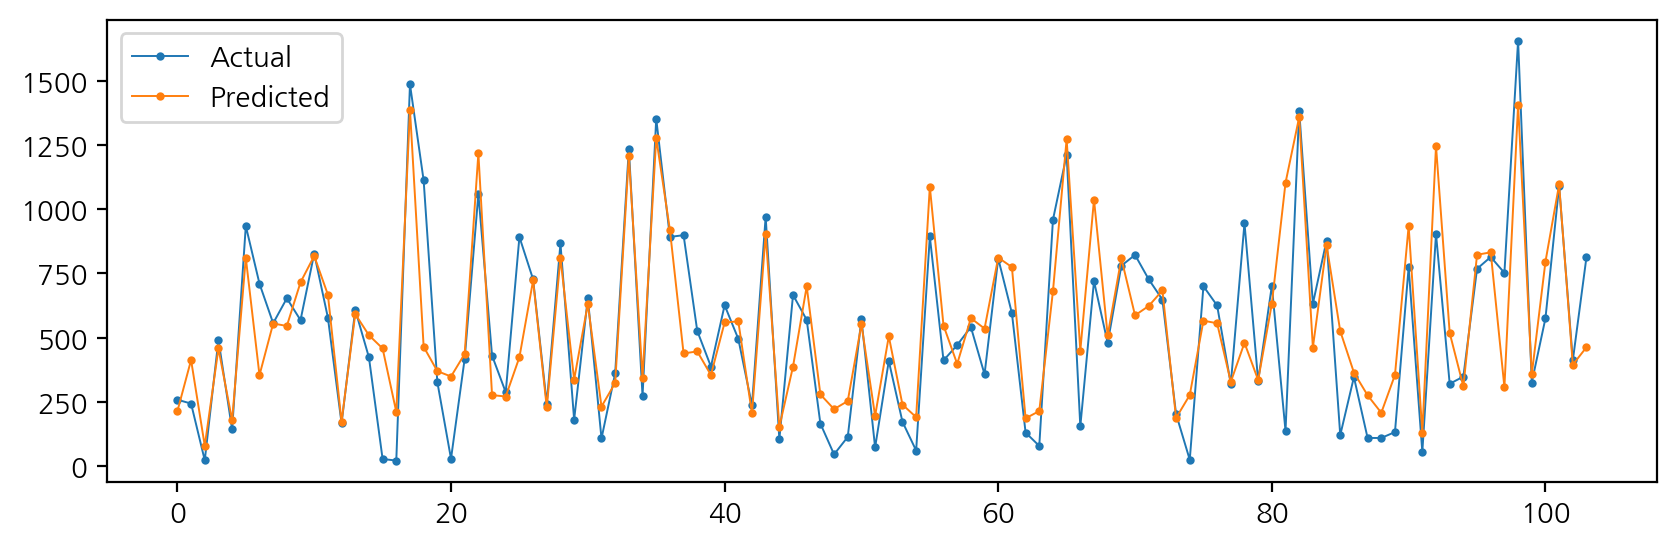

In [669]:
model_plot(y_val, y_pred)

In [508]:
# 파라미터 선언
# max_depth: range(1, 51)
param = {'max_depth' : range(1, 51)}

# Grid Search 선언
# cv=5
# scoring='accuracy'
model = GridSearchCV(model4,
                     param,
                     scoring='r2')

# 학습하기
model.fit(x_train, y_train)

# mean_test_score 확인
print(model.cv_results_['mean_test_score'])

# 최적 파라미터
print(model.best_params_)

# 최고 성능
print(model.best_score_)

[0.50787804 0.68156888 0.73771328 0.74582713 0.75113885 0.74989347
 0.74575143 0.7520814  0.74812829 0.75251365 0.75279785 0.75049854
 0.74724361 0.7457308  0.73988763 0.74998208 0.75281657 0.74498617
 0.75342548 0.74773738 0.75788995 0.7444684  0.75319813 0.7514096
 0.74627285 0.74660502 0.74909378 0.74532922 0.75073749 0.74899932
 0.74582753 0.75201812 0.74492013 0.74368206 0.74791773 0.75284688
 0.74698585 0.75012069 0.74826511 0.74679075 0.74417935 0.74696676
 0.74615004 0.75146058 0.75209959 0.75487007 0.75028636 0.74791493
 0.74976934 0.74978056]
{'max_depth': 21}
0.7578899476386326


<BarContainer object of 20 artists>

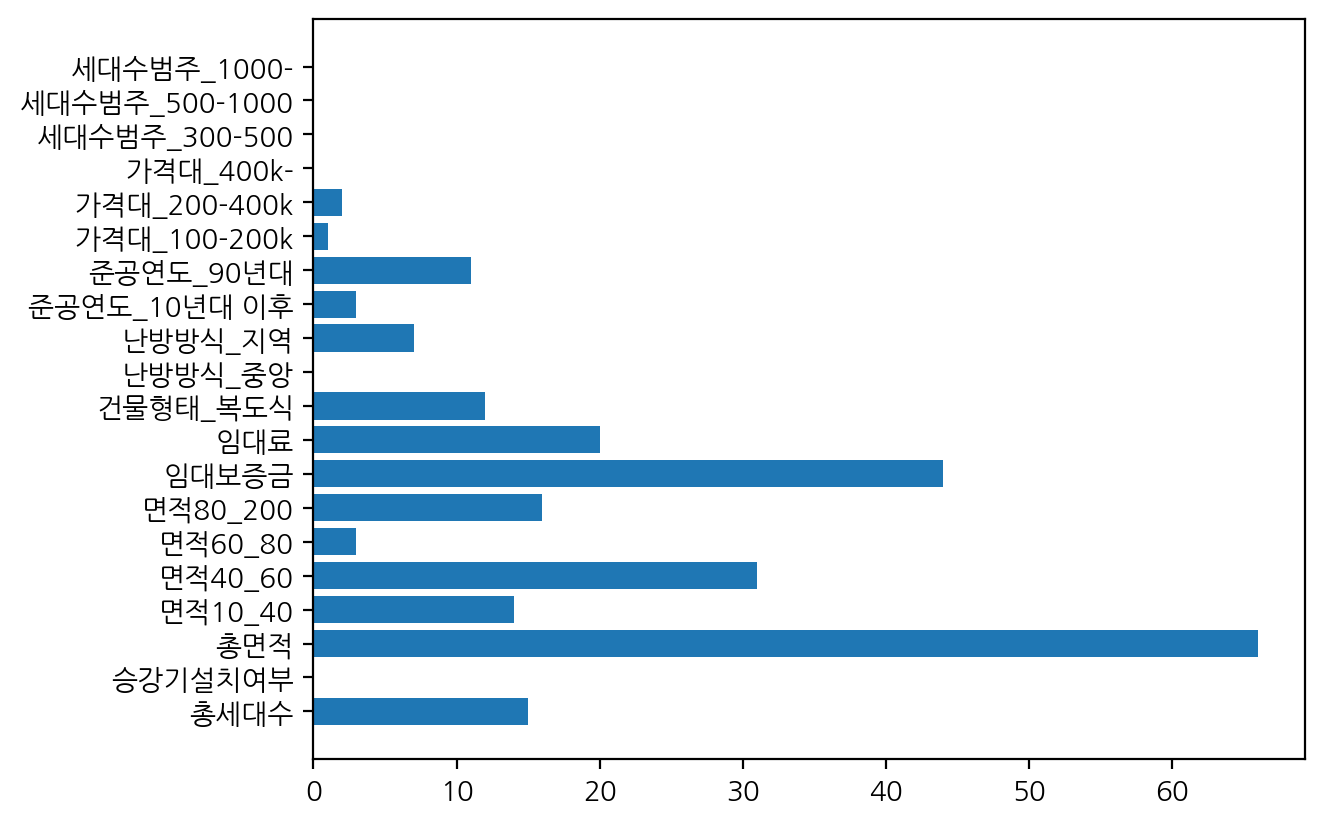

In [551]:
# 변수 중요도
plt.barh(y=list(x), width=model.best_estimator_.feature_importances_)

### (6) 모델 5: 알고리즘

In [653]:
model5 = XGBRegressor(max_depth=7)

cv_score = cross_val_score(model5, x_train_s, y_train, cv=10)

# 확인
print(cv_score)
print('평균:', cv_score.mean())
print('표준편차:', cv_score.std())

# 결과
result['XGB'] = cv_score.mean()
print(result)

[0.75122375 0.73462748 0.58244392 0.36103879 0.777913   0.40413048
 0.81138051 0.78846559 0.76380729 0.6033267 ]
평균: 0.657835750079507
표준편차: 0.15556892910000114
{'LinearRegression': {'MAE': 152.52937685533968, 'R2': 0.6323668398840172}, 'KNN': {'MAE': 160.94917582417582, 'R2': 0.6059771188529661}, 'DecisionTree': {'MAE': 154.17152471066944, 'R2': 0.6171908101206828}, 'RandomForest': {'MAE': 133.53000349287367, 'R2': 0.6926149412770335}, 'XGB': 0.657835750079507}


In [654]:
model5 = XGBRegressor(max_depth=7)

model5.fit(x_train, y_train)
y_pred = model5.predict(x_val)

mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print('MAE:', mae)
print('R2:', r2)

result['XGB'] = {'MAE':mae, 'R2':r2}
print(result)

MAE: 144.26633916909879
R2: 0.6375327047364406
{'LinearRegression': {'MAE': 152.52937685533968, 'R2': 0.6323668398840172}, 'KNN': {'MAE': 160.94917582417582, 'R2': 0.6059771188529661}, 'DecisionTree': {'MAE': 154.17152471066944, 'R2': 0.6171908101206828}, 'RandomForest': {'MAE': 133.53000349287367, 'R2': 0.6926149412770335}, 'XGB': {'MAE': 144.26633916909879, 'R2': 0.6375327047364406}}


In [518]:
# 파라미터 선언
# max_depth: range(1, 51)
param = {'max_depth' : range(1, 51)}

# Grid Search 선언
# cv=5
# scoring='accuracy'
model = GridSearchCV(model5,
                     param,
                     scoring='r2')

# 학습하기
model.fit(x_train, y_train)

# mean_test_score 확인
print(model.cv_results_['mean_test_score'])

# 최적 파라미터
print(model.best_params_)

# 최고 성능
print(model.best_score_)

[0.70920718 0.69975048 0.70642977 0.73367194 0.74349717 0.72420374
 0.70978304 0.68845314 0.68119644 0.69376991 0.70664332 0.70692942
 0.7062982  0.70840991 0.70570166 0.70763111 0.70901812 0.70912696
 0.70957994 0.70964322 0.70964632 0.70963343 0.70963311 0.70963073
 0.70963295 0.70963117 0.70963054 0.70963032 0.70963002 0.70963099
 0.70963104 0.70963104 0.70963104 0.70963104 0.70963104 0.70963104
 0.70963104 0.70963104 0.70963104 0.70963104 0.70963104 0.70963104
 0.70963104 0.70963104 0.70963104 0.70963104 0.70963104 0.70963104
 0.70963104 0.70963104]
{'max_depth': 5}
0.7434971654407778


### (7) 모델 6: 알고리즘

In [657]:
model6 = LGBMRegressor(max_depth=7, verbose=-1)

cv_score = cross_val_score(model6, x_train_s, y_train, cv=10)

# 확인
print(cv_score)
print('평균:', cv_score.mean())
print('표준편차:', cv_score.std())

# 결과
result['LGBM'] = cv_score.mean()
print(result)

[0.80154166 0.74001224 0.78937484 0.75045881 0.77509628 0.32710443
 0.83860753 0.80721768 0.83877404 0.74881314]
평균: 0.7417000656457569
표준편차: 0.14216042952273952
{'LinearRegression': {'MAE': 152.52937685533968, 'R2': 0.6323668398840172}, 'KNN': {'MAE': 160.94917582417582, 'R2': 0.6059771188529661}, 'DecisionTree': {'MAE': 154.17152471066944, 'R2': 0.6171908101206828}, 'RandomForest': {'MAE': 133.53000349287367, 'R2': 0.6926149412770335}, 'XGB': {'MAE': 144.26633916909879, 'R2': 0.6375327047364406}, 'LGBM': 0.7417000656457569}


In [658]:
model6 = LGBMRegressor(max_depth=3, verbose=-1)

model6.fit(x_train, y_train)
y_pred = model6.predict(x_val)

mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print('MAE:', mae)
print('R2:', r2)

result['LGBM'] = {'MAE':mae, 'R2':r2}
print(result)

MAE: 143.83839745593147
R2: 0.6488356919513866
{'LinearRegression': {'MAE': 152.52937685533968, 'R2': 0.6323668398840172}, 'KNN': {'MAE': 160.94917582417582, 'R2': 0.6059771188529661}, 'DecisionTree': {'MAE': 154.17152471066944, 'R2': 0.6171908101206828}, 'RandomForest': {'MAE': 133.53000349287367, 'R2': 0.6926149412770335}, 'XGB': {'MAE': 144.26633916909879, 'R2': 0.6375327047364406}, 'LGBM': {'MAE': 143.83839745593147, 'R2': 0.6488356919513866}}


In [525]:
# 파라미터 선언
# max_depth: range(1, 51)
param = {'max_depth' : range(1, 51)}

# Grid Search 선언
# cv=5
# scoring='accuracy'
model = GridSearchCV(model6,
                     param,
                     scoring='r2')

# 학습하기
model.fit(x_train, y_train)

# mean_test_score 확인
print(model.cv_results_['mean_test_score'])

# 최적 파라미터
print(model.best_params_)

# 최고 성능
print(model.best_score_)

[0.7270326  0.7448212  0.72794849 0.72838212 0.72565199 0.72898444
 0.72839168 0.72839168 0.72839168 0.72839168 0.72839168 0.72839168
 0.72839168 0.72839168 0.72839168 0.72839168 0.72839168 0.72839168
 0.72839168 0.72839168 0.72839168 0.72839168 0.72839168 0.72839168
 0.72839168 0.72839168 0.72839168 0.72839168 0.72839168 0.72839168
 0.72839168 0.72839168 0.72839168 0.72839168 0.72839168 0.72839168
 0.72839168 0.72839168 0.72839168 0.72839168 0.72839168 0.72839168
 0.72839168 0.72839168 0.72839168 0.72839168 0.72839168 0.72839168
 0.72839168 0.72839168]
{'max_depth': 2}
0.7448211993015708


### (7) 성능 비교

- 각 모델의 성능을 비교합니다.

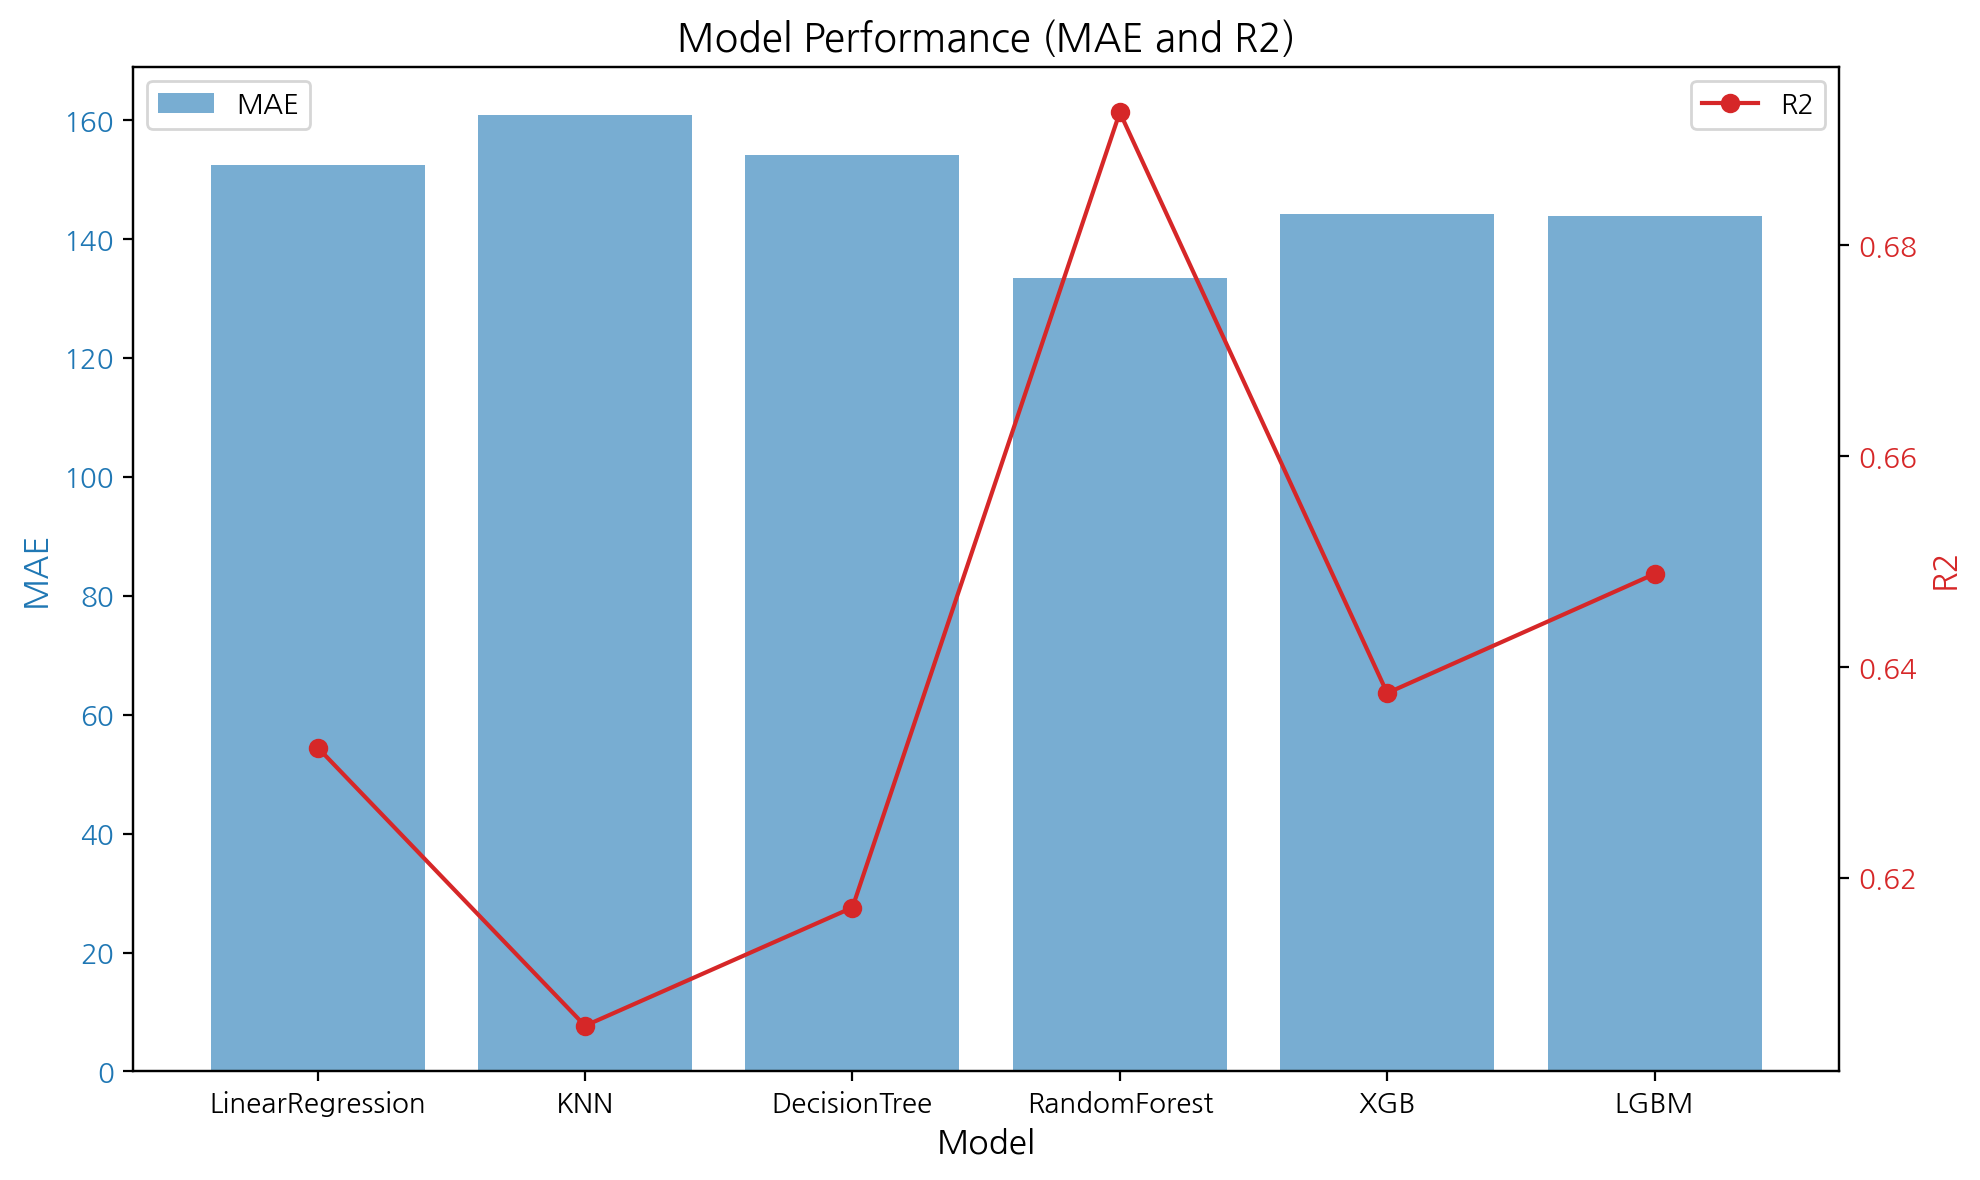

In [661]:
# 데이터프레임으로 변환
df = pd.DataFrame(result).T

# 그래프 설정
fig, ax1 = plt.subplots(figsize=(10, 6))

# 첫 번째 y축 - MAE 막대그래프
ax1.set_xlabel('Model', fontsize=12)
ax1.set_ylabel('MAE', fontsize=12, color='tab:blue')
ax1.bar(df.index, df['MAE'], color='tab:blue', alpha=0.6, label='MAE')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# 두 번째 y축 - R2 선그래프
ax2 = ax1.twinx()
ax2.set_ylabel('R2', fontsize=12, color='tab:red')
ax2.plot(df.index, df['R2'], color='tab:red', marker='o', label='R2')
ax2.tick_params(axis='y', labelcolor='tab:red')

# 그래프 제목
plt.title('Model Performance (MAE and R2)', fontsize=14)

# 레전드 표시
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# 레이아웃 조정
fig.tight_layout()

# 그래프 출력
plt.show()

## 3. 파이프라인 구축

- 새로운 데이터를 불러오고, 이 데이터를 처리할 파이프라인 함수를 만듭니다.

### (1) New Data 불러오기

- test.xlsx 파일을 읽어와 new_data 데이터프레임으로 선언합니다.
- 해당 데이터는 '실차량수' 변수가 없는 것 외에는, 최초 데이터와 동일한 구조입니다.
- 이 데이터를 대상으로 전처리와 예측을 수행합니다.

In [345]:
# 파일 읽어오기
new_data = pd.read_excel(path+'test.xlsx')

# 확인
new_data.head()

,단지코드,단지명,총세대수,전용면적별세대수,지역,준공일자,건물형태,난방방식,승강기설치여부,단지내주차면수,전용면적,공용면적,임대보증금,임대료
0,C0005,서울석촌 도시형주택(공임10년),20,6,서울,20121115,복도식,개별가스난방,전체동 설치,9,17.53,11.7251,50449000,263710
1,C0005,서울석촌 도시형주택(공임10년),20,10,서울,20121115,복도식,개별가스난방,전체동 설치,9,24.71,16.5275,52743000,321040
2,C0005,서울석촌 도시형주택(공임10년),20,4,서울,20121115,복도식,개별가스난방,전체동 설치,9,26.72,17.8720,53890000,332510
3,C0017,대구혁신센텀힐즈,822,228,대구경북,20180221,계단식,지역난방,NaN,824,51.87,20.9266,29298000,411200
4,C0017,대구혁신센텀힐즈,822,56,대구경북,20180221,계단식,지역난방,NaN,824,59.85,24.1461,38550000,462600


In [347]:
new_data.isna().sum()

단지코드        0
단지명         0
총세대수        0
전용면적별세대수    0
지역          0
준공일자        0
건물형태        4
난방방식        1
승강기설치여부     9
단지내주차면수     0
전용면적        0
공용면적        0
임대보증금       0
임대료         0
dtype: int64

### (2) 데이터 파이프라인 구축

- 데이터 파이프라인 함수를 만듭니다.
- 학습 데이터에 대해 진행했던 모든 전처리 과정을 평가 데이터에도 일괄 진행해야 합니다.
    - 입력: new_data
    - 출력: 전처리가 완료된 예측 직전 데이터프레임
- 새로운 데이터에는 '실차량수' 변수가 없음을 유의합니다.
- 참고: 다음 내용들이 처리되어야 합니다.
    - 결측치 처리
    - 변수 추가
    - 불필요한 변수 제거
    - 단지 데이터, 상세 데이터 분리
    - 단지코드별 총면적 합 집계
    - 전용면적 구간별 집계 (피벗 형태)
    - 임대보증금, 임대료 평균 집계
    - 집계 결과 병합
    - 난방방식: 개별, 지역, 중앙 세 가지로 묶기
    - 승강기설치여부: 0, 1 값으로 변경
    - 단지모드, 지역 변수 제거
    - 가변수화

In [350]:
# 파이프라인 만들기
def data_pipeline(data):
    apt01 = data.copy()

    # 결측치 처리
    apt01['건물형태'].fillna(apt01['건물형태'].mode()[0], inplace=True)
    apt01['난방방식'].fillna(apt01['난방방식'].mode()[0], inplace=True)
    apt01['승강기설치여부'].fillna(apt01['승강기설치여부'].mode()[0], inplace=True)

    # 변수 추가
    apt01['준공연도'] = apt01['준공일자']//10000
    apt01['총면적'] = (apt01['전용면적'] + apt01['공용면적']) * apt01['전용면적별세대수']

    # 불필요한 변수 제거
    drop_cols = ['단지명', '단지내주차면수', '준공일자']
    apt01.drop(columns=drop_cols, inplace=True)

    # 단지별 데이터 분리
    data01 = pd.DataFrame()
    data01 = apt01[['단지코드', '총세대수', '지역', '준공연도', '건물형태', '난방방식', '승강기설치여부']]
    data01.drop_duplicates(inplace=True)
    data01.reset_index(drop=True, inplace=True)

    # 상세 데이터 분리
    data02 = pd.DataFrame()
    data02 = apt01[['단지코드', '총면적', '전용면적별세대수', '전용면적', '공용면적', '임대보증금', '임대료']]

    # 단지코드별 총 면적 합 집계
    df_area = data02.groupby('단지코드', as_index=False)[['총면적']].sum()

    # 전용면적 구간별 집계
    data02['전용면적구간'] = pd.cut(data02['전용면적'], bins=[10, 40, 60, 80, 200], labels=['면적10_40', '면적40_60', '면적60_80', '면적80_200'])

    # 단지코드, 전용면적구간 별 전용면적별세대수 합 집계
    temp = data02.groupby(['단지코드', '전용면적구간'], as_index=False)[['전용면적별세대수']].sum()

    # 전용면적구간 피벗팅
    df_pivot = temp.pivot(index='단지코드', columns='전용면적구간', values='전용면적별세대수')
    df_pivot.reset_index(drop=False, inplace=True)
    df_pivot.columns.name=None

    # 단지코드별 임대보증금, 임대료 평균 집계
    df_rent_t=data02.groupby(['단지코드','전용면적별세대수'], as_index=False)[['임대보증금','임대료']].mean()
    df_rent_t['임대보증금'] = df_rent_t['임대보증금'] * df_rent_t['전용면적별세대수']
    df_rent_t['임대료'] = df_rent_t['임대료'] * df_rent_t['전용면적별세대수']
    df_rent_t1 = df_rent_t.groupby(['단지코드'], as_index=False)[['임대보증금','임대료']].sum()
    df_rent_t2 = df_rent_t.groupby(['단지코드'], as_index=False)[['전용면적별세대수']].sum()
    
    df_rent_t = pd.merge(df_rent_t1, df_rent_t2, on='단지코드')
    df_rent_t['임대보증금'] = df_rent_t['임대보증금'] / df_rent_t['전용면적별세대수']
    df_rent_t['임대료'] = df_rent_t['임대료'] / df_rent_t['전용면적별세대수']
    df_rent_t.drop(columns='전용면적별세대수', inplace=True)

    # 집계 결과 합치기
    data01 = pd.merge(data01, df_area, how='left', on='단지코드')
    data01 = pd.merge(data01, df_pivot, how='left', on='단지코드')
    base_data = pd.merge(data01, df_rent_t, how='left', on='단지코드')

    # 난방방식 범주 수정
    base_data.loc[base_data['난방방식'].str.contains('개별'), '난방방식'] = '개별'
    base_data.loc[base_data['난방방식'].str.contains('지역'), '난방방식'] = '지역'
    base_data.loc[base_data['난방방식'].str.contains('중앙'), '난방방식'] = '중앙'

    # 범주 수정
    base_data['승강기설치여부'] = np.where(base_data['승강기설치여부'] == '전체동 설치', 1, 0)

    base_data['건물형태'] = np.where(base_data['건물형태'] == '복도식', '복도식', '계단식')

    base_data['준공연도'] = np.where(base_data['준공연도'] < 2000, '90년대', np.where(base_data['준공연도'] < 2010, '00년대', '10년대 이후'))

    # 수치형 변수 범주형 변수로 수정
    base_data['가격대'] = pd.cut(base_data['임대료'], 
                                 bins=[-np.inf, 100000, 200000, 400000, np.inf], 
                                 labels=['-100k', '100-200k', '200-400k', '400k-'])

    base_data['세대수범주'] = pd.cut(base_data['총세대수'], 
                             bins=[-np.inf, 300, 500, 1000, np.inf], 
                             labels=['-300', '300-500','500-1000','1000-'])

    # 불필요한 변수 제거
    drop_cols = ['단지코드', '지역']
    base_data.drop(columns=drop_cols, inplace=True)

    # 가변수화
    dumm_cols = ['건물형태', '난방방식', '준공연도', '가격대', '세대수범주']
    data = pd.get_dummies(base_data, columns=dumm_cols, drop_first=True, dtype=int)

    return data

### (3) 예측하기

- new_data를 파이프라인을 사용해 전처리한 후 가장 성능이 좋았던 모델로 예측한 결과를 확인합니다.

In [597]:
# 데이터 전처리
data = data_pipeline(new_data)

# 확인
data.head()

,총세대수,승강기설치여부,총면적,면적10_40,면적40_60,면적60_80,면적80_200,임대보증금,임대료,건물형태_복도식,난방방식_중앙,난방방식_지역,준공연도_10년대 이후,준공연도_90년대,가격대_100-200k,가격대_200-400k,가격대_400k-,세대수범주_300-500,세대수범주_500-1000,세대수범주_1000-
0,20,1,766.2736,20,0,0,0,5.228420e+07,306135.000000,1,0,0,1,0,0,1,0,0,0,0
1,822,1,31396.0944,0,404,0,0,3.332857e+07,433592.079208,0,0,1,1,0,0,0,1,0,1,0
2,112,1,12450.4308,0,0,20,92,1.048609e+08,773455.714286,0,0,1,1,0,0,0,1,0,0,0
3,122,1,13081.4772,0,0,22,100,0.000000e+00,0.000000,0,0,1,1,0,0,0,0,0,0,0
4,262,1,28141.7516,0,0,77,185,0.000000e+00,0.000000,0,0,1,1,0,0,0,0,0,0,0


In [396]:
model4.fit(x_train, y_train)

# 예측하기
predicted = model4.predict(data)

# 확인
print(predicted)

[ 184.67332794  441.72684366  548.59053692  538.92279662  760.54627778
  328.84414127  452.50903765  767.77880191  466.55654031  360.20764806
  252.28170666  201.7926588  1416.79083333  668.05826185  523.62734085
  648.53773426  609.47171683  212.97352347 1062.09448107 1002.97781918
  269.19332562  805.19865515  848.2187781   836.02882206  913.93824095
  261.41753299  141.843943   1289.02071465  238.03363806  718.70524305]


- 아파트 기본 정보에 예측한 차량수를 붙여 마무리합니다.

In [399]:
# 데이터 셋 두개로 나누기
vars = ['단지코드', '단지명', '총세대수', '지역', ]
result = new_data[vars].copy()
result = result.drop_duplicates()
result.reset_index(drop=True, inplace=True)

# 예측 결과 추가
result['예상차량수'] = predicted.round(1).astype(int)

# 확인
result

,단지코드,단지명,총세대수,지역,예상차량수
0,C0005,서울석촌 도시형주택(공임10년),20,서울,184
1,C0017,대구혁신센텀힐즈,822,대구경북,441
2,C0034,광교 호반마을 22단지 아파트,112,경기,548
3,C0046,죽미마을 휴먼시아12단지,122,경기,538
4,C0055,파주운정 한울마을 6단지,262,경기,760
5,C0072,벌교제석휴먼시아,35,광주전남,328
6,C0073,무안남악오룡마을,47,광주전남,452
7,C0084,진해 석동우림필유 아파트,152,경남,767
8,C0085,김해북부 두산위브 아파트,73,경남,466
9,C0112,운암주공6단지아파트,571,경기,360
